In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


In [2]:

dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).round(1)


df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60], 
                         labels=['18-25','26-35','36-45','46-60'])
age = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).round(1)


income = df.groupby('Attrition')['MonthlyIncome'].mean().round(0)


overtime = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).round(1)

print("Attrition by Department (%):")
print(dept)
print("\nAttrition by Age Group (%):")
print(age)
print("\nAvg Monthly Income:")
print(income)
print("\nAttrition by Overtime (%):")
print(overtime)

Attrition by Department (%):
Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64

Attrition by Age Group (%):
AgeGroup
18-25    34.8
26-35    19.1
36-45     9.2
46-60    12.5
Name: Attrition, dtype: float64

Avg Monthly Income:
Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64

Attrition by Overtime (%):
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64


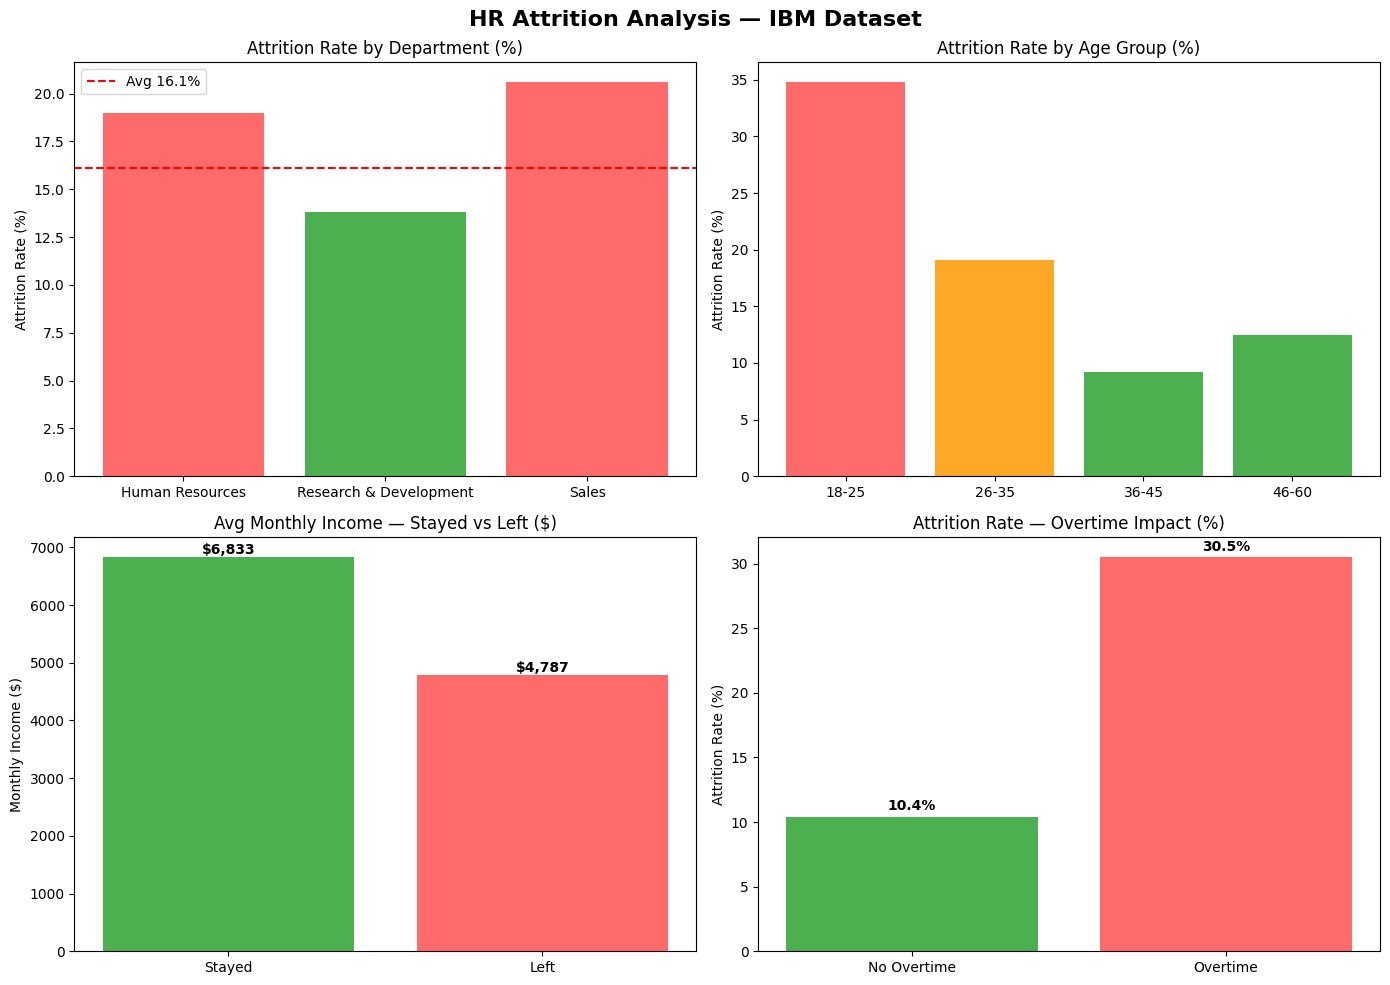

HR Dashboard saved!


In [3]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Attrition Analysis — IBM Dataset', 
             fontsize=16, fontweight='bold')


colors1 = ['#FF6B6B' if x > 15 else '#4CAF50' for x in dept.values]
axes[0, 0].bar(dept.index, dept.values, color=colors1)
axes[0, 0].set_title('Attrition Rate by Department (%)')
axes[0, 0].set_ylabel('Attrition Rate (%)')
axes[0, 0].axhline(y=16.1, color='red', linestyle='--', 
                    label='Avg 16.1%')
axes[0, 0].legend()


colors2 = ['#FF6B6B' if x > 20 else '#FFA726' 
           if x > 15 else '#4CAF50' for x in age.values]
axes[0, 1].bar(age.index, age.values, color=colors2)
axes[0, 1].set_title('Attrition Rate by Age Group (%)')
axes[0, 1].set_ylabel('Attrition Rate (%)')


colors3 = ['#4CAF50', '#FF6B6B']
axes[1, 0].bar(['Stayed', 'Left'], income.values, color=colors3)
axes[1, 0].set_title('Avg Monthly Income — Stayed vs Left ($)')
axes[1, 0].set_ylabel('Monthly Income ($)')
for i, v in enumerate(income.values):
    axes[1, 0].text(i, v + 50, f'${v:,.0f}', 
                    ha='center', fontweight='bold')


colors4 = ['#4CAF50', '#FF6B6B']
axes[1, 1].bar(['No Overtime', 'Overtime'], 
               overtime.values, color=colors4)
axes[1, 1].set_title('Attrition Rate — Overtime Impact (%)')
axes[1, 1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(overtime.values):
    axes[1, 1].text(i, v + 0.5, f'{v}%', 
                    ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('hr_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("HR Dashboard saved!")

Accuracy: 87.4%
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.62      0.13      0.21        39

    accuracy                           0.87       294
   macro avg       0.75      0.56      0.57       294
weighted avg       0.85      0.87      0.84       294


Top 10 Factors causing Attrition:
               Feature  Importance
15       MonthlyIncome    0.082055
18            OverTime    0.066453
0                  Age    0.060075
2            DailyRate    0.051319
16         MonthlyRate    0.049834
9           HourlyRate    0.046323
23   TotalWorkingYears    0.044803
26      YearsAtCompany    0.044615
4     DistanceFromHome    0.044407
17  NumCompaniesWorked    0.034470


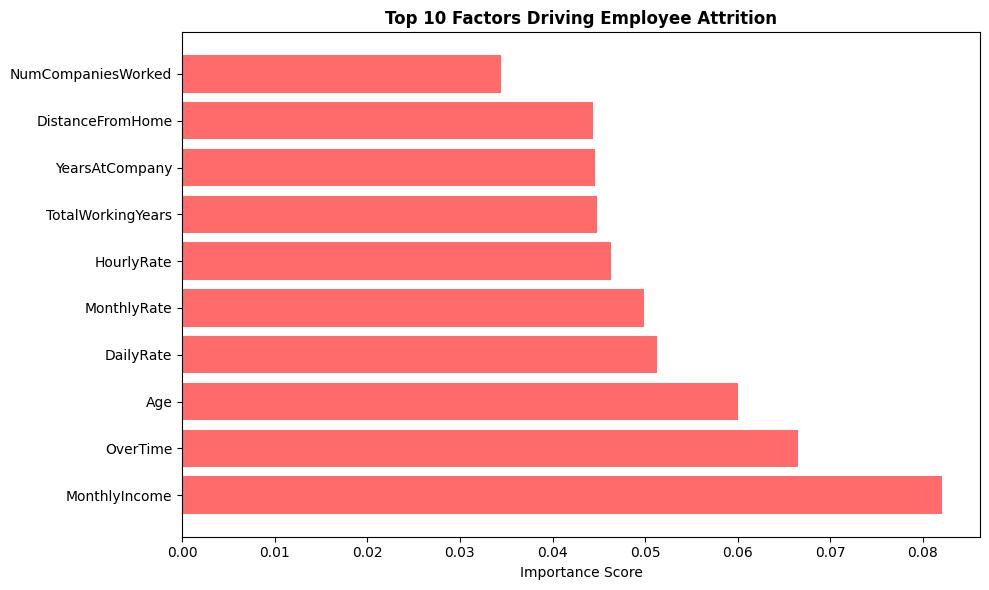

In [4]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


df_model = df.copy()
le = LabelEncoder()
cat_cols = ['Attrition', 'BusinessTravel', 'Department', 
            'EducationField', 'Gender', 'JobRole', 
            'MaritalStatus', 'OverTime', 'AgeGroup']

for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))


df_model = df_model.drop(['EmployeeCount', 'EmployeeNumber', 
                           'Over18', 'StandardHours'], axis=1)


X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(classification_report(y_test, y_pred))


feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Factors causing Attrition:")
print(feat_imp)


plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#FF6B6B')
plt.title('Top 10 Factors Driving Employee Attrition', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('attrition_factors.png', dpi=150)
plt.show()